In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [3]:
def ReLU(preactivation):
  activation= preactivation.clip(0.0)
  return activation

def shallow_nn(x, beta_0, omega_0, beta_1, omega_1):
  n_data= x.size
  x= np.reshape(x,(1,n_data))
  h1= ReLU(np.matmul(beta_0, np.ones((1,n_data))) + np.matmul(omega_0,x))
  y= np.matmul(beta_1, np.ones((1, n_data))) + np.matmul(omega_1, h1)
  return y

In [4]:
def get_parameters():
  beta_0= np.zeros((3,1));
  omega_0= np.zeros((3,1));
  beta_1= np.zeros((1,1));
  omega_1= np.zeros((1,3));

  beta_0[0,0]= 0.1; beta_0[1,0]= 1.0; beta_0[2,0]= -0.5
  omega_0[0,0]= -1.0; omega_0[1,0]= 1.8; omega_0[2,0]= 0.65
  beta_1[0,0]= 0.1;
  omega_1[0,0]= -2.0; omega_1[0,1]= -1.0; omega_1[0,2]= 7.0

  return beta_0, omega_0, beta_1, omega_1

In [9]:
def plot_univariate_regression(x_model, y_model, x_data= None, y_data= None, sigma_model= None, title= None):
  x_model= np.squeeze(x_model)
  y_model= np.squeeze(y_model)

  fig, ax= plt.subplots()
  ax.plot(x_model, y_model)
  if sigma_model is not None:
    ax.fill_between(x_model, y_model-2*sigma_model, y_model+2*sigma_model, color='lightgray')
  ax.set_xlabel (r'Input, x'); ax.set_ylabel(r'output y')
  ax.set_xlim([0,1]);ax.set_ylim([-1,1])
  ax.set_aspect(0.5)
  if title is not None:
    ax.set_title(title)
  if x_data is not None:
    ax.plot(x_data, y_data, 'ko')
  plt.show()

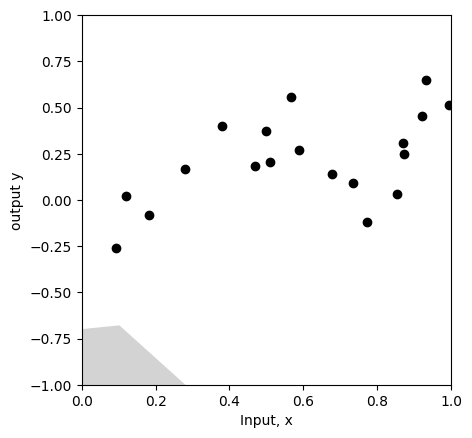

In [10]:
x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.25934537,0.18195445,0.651270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.20716968,-0.08131792,0.51187806,0.16943738,0.3994327,\
                    0.019062570,0.55820410,0.452564960,-0.1183121,0.02957665,-1.24354444, \
                    0.248038840,0.26824970])

beta_0, omega_0, beta_1, omega_1= get_parameters()
sigma= 0.2
x_model= np.arange(0,1,0.01)
y_model= shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma)

In [13]:
def normal_distribution(y, mu, sigma):
  prob= np.zeros_like(y)
  return prob
print("RESPOSTA CORRETA = %3.3f, SUA RESPOSTA = %3.3f"%(0.119,normal_distribution(1,-1,2.3)))

RESPOSTA CORRETA = 0.119, SUA RESPOSTA = 0.000


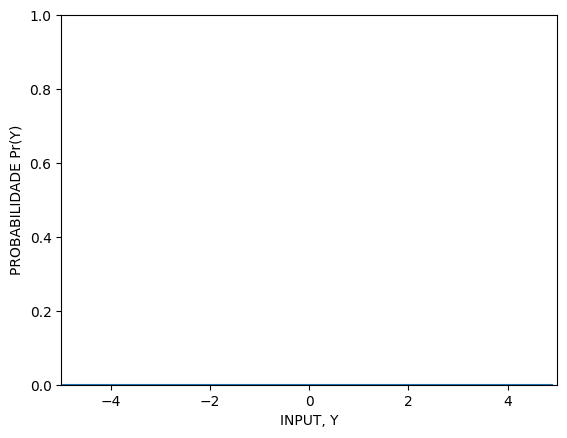

In [14]:
y_gauss= np.arange(-5, 5, 0.1)
mu= 0; sigma= 1.0
gauss_prob= normal_distribution(y_gauss, mu, sigma)
fig,ax= plt.subplots()
ax.plot(y_gauss, gauss_prob)
ax.set_xlabel(r'INPUT, Y'); ax.set_ylabel(r'PROBABILIDADE Pr(Y)')
ax.set_xlim([-5,5]); ax.set_ylim([0,1.0])
plt.show()

In [15]:
def compute_likelihood(y_train, mu, sigma):
  likelihood= 0
  return likelihood

In [16]:
beta_0, omega_0, beta_1, omega_1= get_parameters()
mu_pred= shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
sigma= 0.2

likelihood= compute_likelihood(y_train, mu_pred, sigma)
print("RESPOSTA CORRETA = %9.9f, SUA RESPOSTA = %9.9f"%(0.000010624,likelihood))

RESPOSTA CORRETA = 0.000010624, SUA RESPOSTA = 0.000000000


In [17]:
def compute_negative_log_likelihood(y_train, mu, sigma):
  nll= 0
  return nll

In [19]:
beta_0, omega_0, beta_1, omega_1= get_parameters()
mu_pred= shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
sigma= 0.2
nll= compute_negative_log_likelihood(y_train, mu_pred, sigma)
print("RESPOSTA CORRETA= %9.9f, SUA RESPOSTA  = %9.9f"%(11.452419564,nll))

RESPOSTA CORRETA= 11.452419564, SUA RESPOSTA  = 0.000000000


In [20]:
def compute_sum_of_squares(y_train, y_pred):
  sum_of_squares= 0;
  return sum_of_squares

In [21]:
beta_0, omega_0, beta_1, omega_1= get_parameters()
y_pred= mu_pred= shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
sum_of_squares= compute_sum_of_squares(y_train, y_pred)
print("RESPOSTA CORRETA= %9.9f, SUA RESPOSTA  = %9.9f"%(2.020992572,sum_of_squares))

RESPOSTA CORRETA= 2.020992572, SUA RESPOSTA  = 0.000000000


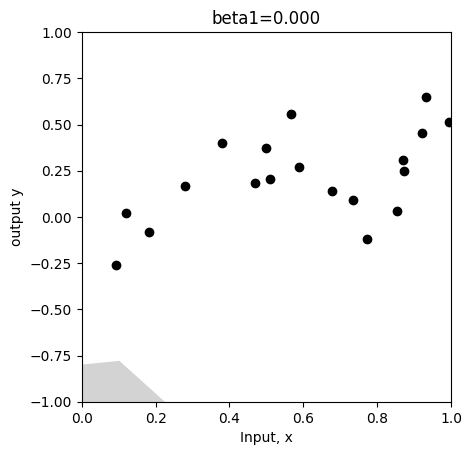

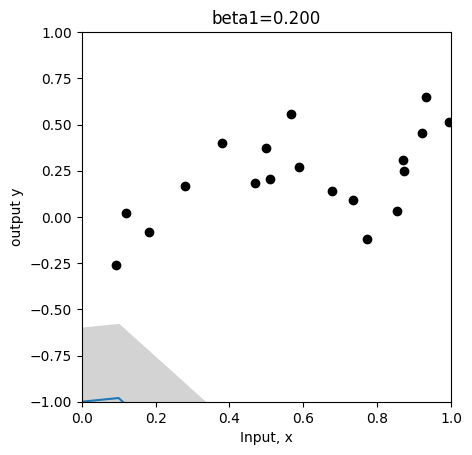

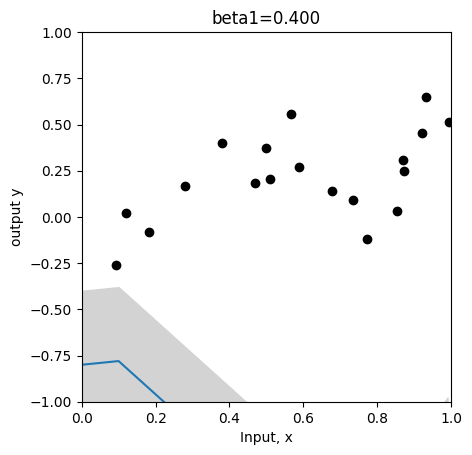

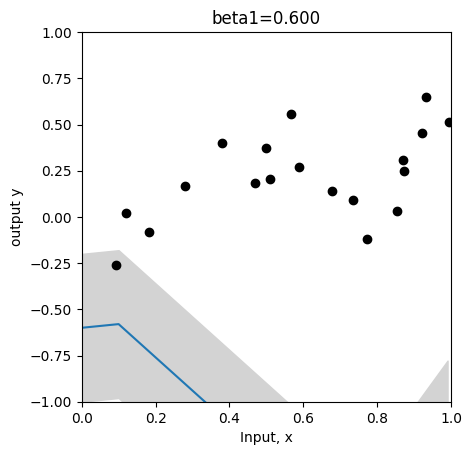

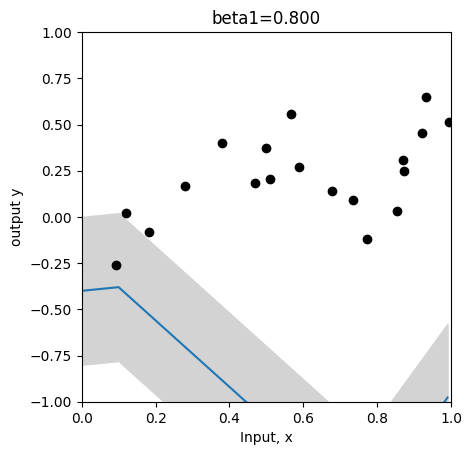

In [25]:
beta_1_vals= np.arange(0,1.0,0.01)
likelihood= np.zeros_like(beta_1_vals)
nll= np.zeros_like(beta_1_vals)
sum_squares= np.zeros_like(beta_1_vals)

beta_0, omega_0, beta_1, omega_1= get_parameters()
sigma= 0.2
for count in range(len(beta_1_vals)):
  beta_1[0,0]= beta_1_vals[count]
  mu_pred= y_pred= shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
  likelihood[count]= compute_likelihood(y_train, mu_pred, sigma)
  nll[count]= compute_negative_log_likelihood(y_train, mu_pred, sigma)
  sum_squares[count]= compute_sum_of_squares(y_train, y_pred)

  if count % 20 == 0:
    y_model= shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
    plot_univariate_regression(x_model, y_model, x_train, y_train, sigma_model = sigma, title="beta1=%3.3f"%(beta_1[0,0]))

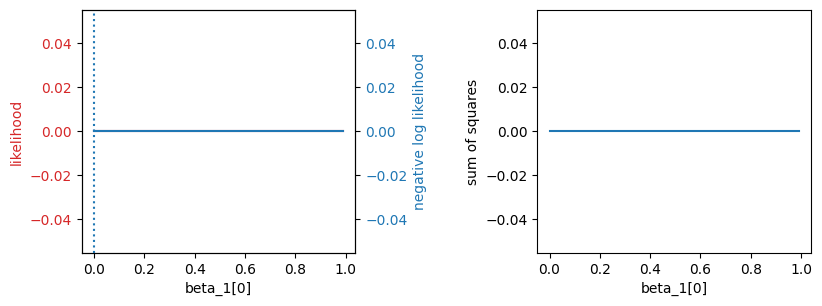

In [27]:
fig, ax= plt.subplots(1,2)
fig.set_size_inches(10.5, 5.5)
fig.tight_layout(pad=10.0)
likelihood_color= 'tab:red'
nll_color= 'tab:blue'

ax[0].set_xlabel('beta_1[0]')
ax[0].set_ylabel('likelihood', color= likelihood_color)
ax[0].plot(beta_1_vals, likelihood, color= likelihood_color)
ax[0].tick_params(axis='y', labelcolor= likelihood_color)

ax00= ax[0].twinx()
ax00.plot(beta_1_vals, nll, color= nll_color)
ax00.set_ylabel('negative log likelihood', color= nll_color)
ax00.tick_params(axis='y', labelcolor= nll_color)

plt.axvline(x= beta_1_vals[np.argmax(likelihood)], linestyle='dotted')
ax[1].plot(beta_1_vals, sum_squares); ax[1].set_xlabel('beta_1[0]'); ax[1].set_ylabel('sum of squares')
plt.show()